# FraudShield — Feature Engineering Pipeline
**Goal:** Run `FraudFeaturePipeline` on the IEEE-CIS dataset, validate outputs, and save `data/processed/train.parquet` + `test.parquet` for model training in Step 5.

**Split strategy:** Time-based — day < 145 for train (~80%), day >= 145 for test (~20%).  
Random splits leak future information into training. We always split by time.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features.pipeline import FraudFeaturePipeline
from src.features.constants import TRAIN_TEST_SPLIT_DAY

DATA_RAW = '../data/raw/ieee-fraud-detection'
DATA_PROCESSED = '../data/processed'
os.makedirs(DATA_PROCESSED, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Load and Merge Raw Data

In [2]:
trans = pd.read_csv(f'{DATA_RAW}/train_transaction.csv')
ident = pd.read_csv(f'{DATA_RAW}/train_identity.csv')
df = trans.merge(ident, on='TransactionID', how='left')

print(f'Merged: {df.shape[0]:,} rows x {df.shape[1]} cols')

Merged: 590,540 rows x 434 cols


## 2. Time-Based Train / Test Split

In [3]:
df['day'] = df['TransactionDT'] // 86400

train_df = df[df['day'] < TRAIN_TEST_SPLIT_DAY].drop(columns='day').reset_index(drop=True)
test_df  = df[df['day'] >= TRAIN_TEST_SPLIT_DAY].drop(columns='day').reset_index(drop=True)

y_train = train_df.pop('isFraud')
y_test  = test_df.pop('isFraud')

print(f'Train : {len(train_df):,} rows  |  fraud rate: {y_train.mean():.3%}')
print(f'Test  : {len(test_df):,} rows  |  fraud rate: {y_test.mean():.3%}')
print(f'Split boundary: day {TRAIN_TEST_SPLIT_DAY}')

/var/folders/y3/m_84hfjd4s37xmg91v6mcbp80000gn/T/ipykernel_81891/2401778410.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day'] = df['TransactionDT'] // 86400


Train : 482,179 rows  |  fraud rate: 3.523%
Test  : 108,361 rows  |  fraud rate: 3.394%
Split boundary: day 145


## 3. Fit Pipeline on Train, Transform Both Sets

In [4]:
pipeline = FraudFeaturePipeline()

X_train = pipeline.fit_transform(train_df, y_train)
X_test  = pipeline.transform(test_df)

print(f'X_train: {X_train.shape}  |  dtype: {X_train.dtypes.unique()}')
print(f'X_test : {X_test.shape}')
print(f'Feature count: {X_train.shape[1]}')

X_train: (482179, 113)  |  dtype: [dtype('float32')]
X_test : (108361, 113)
Feature count: 113


## 4. Validate — No NaN, No Leakage, Correct Types

In [5]:
train_nan = X_train.isnull().sum().sum()
test_nan  = X_test.isnull().sum().sum()

print(f'NaN in X_train : {train_nan}  <- must be 0')
print(f'NaN in X_test  : {test_nan}   <- must be 0')
assert train_nan == 0, 'NaN found in training features!'
assert test_nan  == 0, 'NaN found in test features!'

assert 'isFraud' not in X_train.columns
assert 'isFraud' not in X_test.columns
assert list(X_train.columns) == list(X_test.columns), 'Column mismatch!'
assert (X_train.dtypes == np.float32).all(), 'Not all float32'

print('All checks passed.')

NaN in X_train : 0  <- must be 0
NaN in X_test  : 0   <- must be 0
All checks passed.


## 5. Feature List by Group

In [6]:
features = X_train.columns.tolist()
print(f'Total features: {len(features)}')
print()

groups = {
    'Time':     [f for f in features if f in ['hour_of_day', 'day_of_week']],
    'Amount':   [f for f in features if 'amt' in f],
    'Card':     [f for f in features if f.startswith('card')],
    'C-feat':   [f for f in features if f.startswith('C') and f[1:].isdigit()],
    'D-feat':   [f for f in features if f.startswith('D') and f[1:].isdigit()],
    'M-flags':  [f for f in features if f.startswith('M') and f[1:].isdigit()],
    'V-feat':   [f for f in features if f.startswith('V')],
    'Address':  [f for f in features if f.startswith('addr') or f == 'dist1'],
    'Identity': [f for f in features if f.startswith('id_') or f in ['has_identity', 'device_mobile']],
    'Encoded':  [f for f in features if f in ['card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'ProductCD']],
}

for group, cols in groups.items():
    preview = str(cols[:4])[:-1] + '...]' if len(cols) > 4 else str(cols)
    print(f'  {group:<12} {len(cols):3}  {preview}')

Total features: 113

  Time           2  ['hour_of_day', 'day_of_week']
  Amount         2  ['amt_log', 'amt_zscore']
  Card           6  ['card1', 'card2', 'card3', 'card4'...]
  C-feat        14  ['C1', 'C2', 'C3', 'C4'...]
  D-feat         9  ['D1', 'D2', 'D3', 'D4'...]
  M-flags        9  ['M1', 'M2', 'M3', 'M4'...]
  V-feat        50  ['V12', 'V13', 'V17', 'V18'...]
  Address        3  ['addr1', 'addr2', 'dist1']
  Identity      15  ['id_01', 'id_02', 'id_05', 'id_06'...]
  Encoded        5  ['ProductCD', 'card4', 'card6', 'P_emaildomain'...]


## 6. Distribution Check — Key Engineered Features

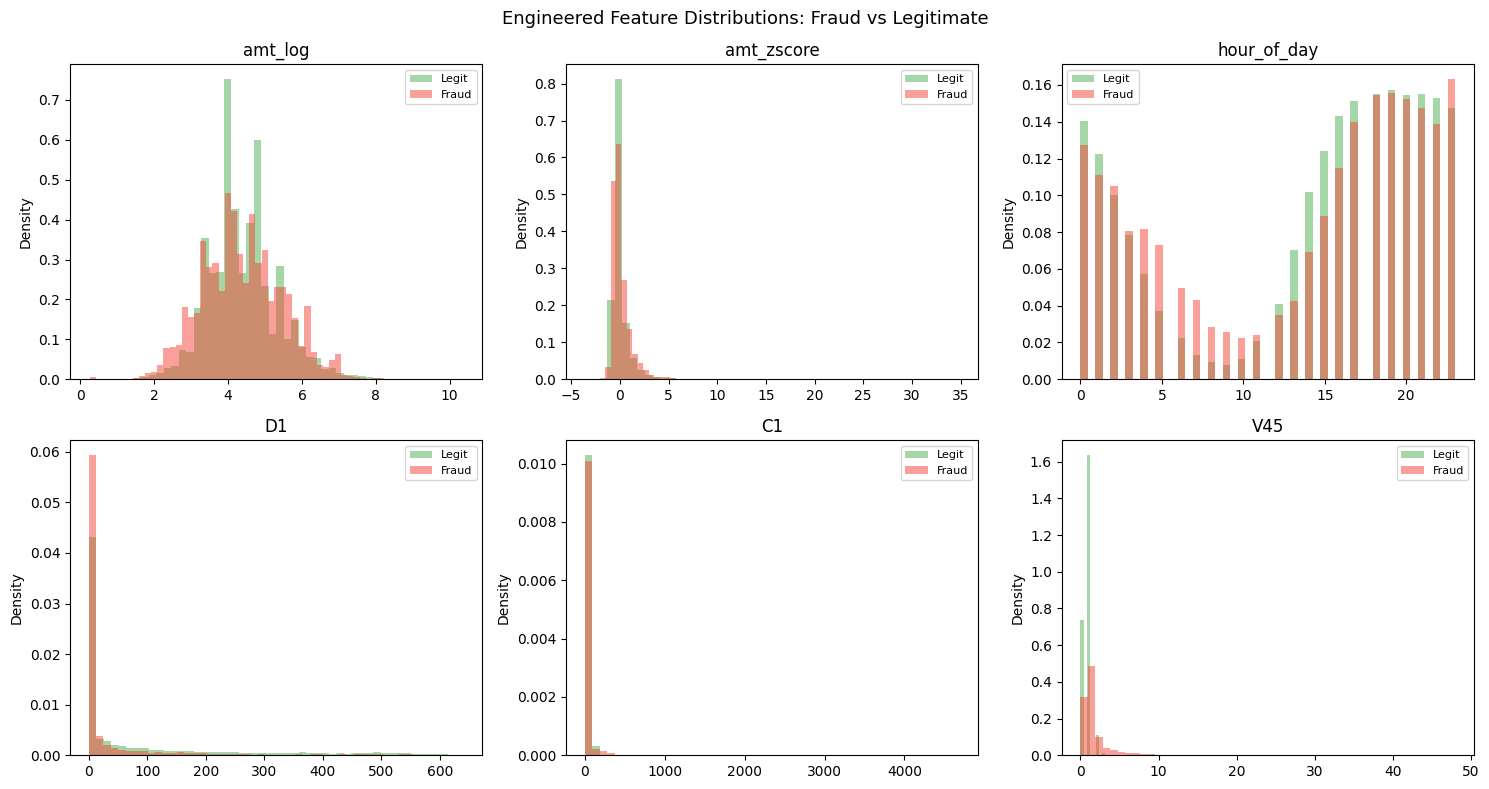

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

check_features = ['amt_log', 'amt_zscore', 'hour_of_day', 'D1', 'C1', 'V45']
check_features = [f for f in check_features if f in X_train.columns]

fraud_mask = y_train.values == 1

for i, feat in enumerate(check_features):
    vals = X_train[feat].values
    axes[i].hist(vals[~fraud_mask], bins=50, alpha=0.5, density=True, color='#4CAF50', label='Legit')
    axes[i].hist(vals[fraud_mask],  bins=50, alpha=0.5, density=True, color='#F44336', label='Fraud')
    axes[i].set_title(feat)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Engineered Feature Distributions: Fraud vs Legitimate', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Leakage Check — Target Encoder Fitted on Train Only

In [8]:
te = pipeline.target_encoder_
print('Target encoder fitted on train only. Sample mappings:')
for col in ['card4', 'ProductCD']:
    if col in te.mapping_:
        print(f'\n  {col}:')
        for k, v in list(te.mapping_[col].items())[:5]:
            print(f'    {k}: {v:.4f}')

print(f'\nGlobal mean (train fraud rate): {te.global_mean_:.6f}')
print(f'Actual train fraud rate       : {y_train.mean():.6f}')
assert abs(te.global_mean_ - y_train.mean()) < 1e-6
print('Leakage check passed.')

Target encoder fitted on train only. Sample mappings:

  card4:
    american express: 0.0285
    discover: 0.0766
    mastercard: 0.0350
    visa: 0.0348

  ProductCD:
    C: 0.1138
    H: 0.0463
    R: 0.0363
    S: 0.0610
    W: 0.0209

Global mean (train fraud rate): 0.035226
Actual train fraud rate       : 0.035226
Leakage check passed.


## 8. Save Processed Data and Pipeline

In [9]:
train_out = X_train.copy()
train_out['isFraud'] = y_train.values
test_out = X_test.copy()
test_out['isFraud'] = y_test.values

train_out.to_parquet(f'{DATA_PROCESSED}/train.parquet', index=False)
test_out.to_parquet(f'{DATA_PROCESSED}/test.parquet', index=False)

os.makedirs('../models', exist_ok=True)
pipeline.save('../models/feature_pipeline.joblib')

train_mb = os.path.getsize(f'{DATA_PROCESSED}/train.parquet') / 1e6
test_mb  = os.path.getsize(f'{DATA_PROCESSED}/test.parquet') / 1e6
pipe_mb  = os.path.getsize('../models/feature_pipeline.joblib') / 1e6

print(f'data/processed/train.parquet     {train_mb:.1f} MB')
print(f'data/processed/test.parquet      {test_mb:.1f} MB')
print(f'models/feature_pipeline.joblib   {pipe_mb:.2f} MB')

data/processed/train.parquet     28.0 MB
data/processed/test.parquet      6.4 MB
models/feature_pipeline.joblib   0.31 MB


## 9. Summary

In [10]:
print('=' * 55)
print('FEATURE ENGINEERING SUMMARY')
print('=' * 55)
print(f'Train samples  : {len(X_train):,}  (fraud: {y_train.sum():,})')
print(f'Test  samples  : {len(X_test):,}   (fraud: {y_test.sum():,})')
print(f'Features       : {X_train.shape[1]}')
print(f'Memory         : {X_train.memory_usage(deep=True).sum() / 1e6:.1f} MB (train, float32)')
print(f'NaN check      : PASSED')
print(f'Leakage check  : PASSED')
print(f'Column align   : PASSED')
print()
print('Ready for Step 5: Model Training + MLflow')
print('=' * 55)

FEATURE ENGINEERING SUMMARY
Train samples  : 482,179  (fraud: 16,985)
Test  samples  : 108,361   (fraud: 3,678)
Features       : 113
Memory         : 217.9 MB (train, float32)
NaN check      : PASSED
Leakage check  : PASSED
Column align   : PASSED

Ready for Step 5: Model Training + MLflow
